## Language Modelling: Lab Assignment 
### Neural models for word vector representation

**Authors**:

- 
- 


**University**: Universidade de Santiago de Compostela

**Academic Year**: 2025-2026

---

In [ ]:
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Edit here with GoogleDrive path
    project_path = '/content/drive/MyDrive/LM/'

    if project_path not in sys.path:
        sys.path.insert(0, project_path)
    # If uploaded directly to Colab's temporary storage
    #project_path = '/content/'
    IN_COLAB = True
except:
    IN_COLAB = False
    project_path = ''

In [ ]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

MAX_LENGTH = 128
BATCH_SIZE = 128
EPOCHS = 50
MAX_TOKENS = 20000 # Max length vocabulary -> 20000 (for training the model)
DATASET_PATH = project_path + "data/eng_news_2024_30k_sentences.txt"
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# 90% train, 10 test. Better without early stopping

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

I0000 00:00:1778000104.065751  131439 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
Keras version: 3.14.0


In [3]:
vectorization_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    max_tokens=MAX_TOKENS,
    output_sequence_length=None,#MAX_LENGTH,
)

def load_corpus(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f if line.strip()]

    vectorization_layer.adapt(sentences)

    # vocab gets saved to the vectorization_layer object
    # so it is not needed to return it as an output
    vocab = vectorization_layer.get_vocabulary()
    vocab_size = len(vocab)

    return sentences, vocab_size

def create_training_samples(sentences, n=3):
    integer_sequences = vectorization_layer(sentences).numpy()

    X_train = []
    y_train = []

    for seq in integer_sequences:
        # Apply a mask to remove padding (token id = 0)
        tokens = seq#[seq != 0]
        # Padding at the front
        tokens = np.concatenate([np.zeros(n),tokens])
        # Padding at the back
        tokens = np.concatenate([tokens, np.zeros(n)])

        for i in range(n, len(tokens) - n):
            context = np.concatenate((tokens[i-n:i], tokens[i+1:i+n+1]))
            target = tokens[i]

            if target != 0:
              context = np.concatenate((tokens[i-n:i], tokens[i+1:i+n+1]))
              X_train.append(context)
              y_train.append(target)

    return np.array(X_train), np.array(y_train)


sentences, vocab_size = load_corpus(DATASET_PATH)
vocab = vectorization_layer.get_vocabulary()

word_to_id = {str(word): i for i, word in enumerate(vocab)}
id_to_word = {v: k for k, v in word_to_id.items()}

X, y = create_training_samples(sentences, n=2)

I0000 00:00:1778000106.316400  131439 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38485 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:21:00.0, compute capability: 8.0


In [4]:
def seq_to_sen(sequence, id_to_word):
    try:
        return [id_to_word[int(_id)] for _id in sequence]
    except:
        return id_to_word[int(sequence)]
#seq_to_sen(sentence_int, id_to_word)

In [5]:
for i in range(10):
    print(f"Sentence: {seq_to_sen(X[i], id_to_word)}")
    print(f"Target: {seq_to_sen(y[i], id_to_word)}")

Sentence: ['', '', 'suggested', 'donation']
Target: 1015
Sentence: ['', '1015', 'donation', 'goes']
Target: suggested
Sentence: ['1015', 'suggested', 'goes', 'to']
Target: donation
Sentence: ['suggested', 'donation', 'to', 'falmouth']
Target: goes
Sentence: ['donation', 'goes', 'falmouth', 'land']
Target: to
Sentence: ['goes', 'to', 'land', 'trust']
Target: falmouth
Sentence: ['to', 'falmouth', 'trust', '']
Target: land
Sentence: ['falmouth', 'land', '', '']
Target: trust
Sentence: ['', '', 'lower', '[UNK]']
Target: 20000
Sentence: ['', '20000', '[UNK]', 'pride']
Target: lower


In [6]:
sentences[5]

'… 15 of Mt. View’s 18 regular-season games were against Class B teams.'

In [7]:
sentence = sentences[5]
print(sentence)
sentence_int = vectorization_layer(sentence)
print(sentence_int)
word_seq = [id_to_word[int(_id)] for _id in sentence_int]
print(word_seq)

… 15 of Mt. View’s 18 regular-season games were against Class B teams.
tf.Tensor(
[ 1247   432     5  5493 15248   768  7722   248    41   109  1267  2880
   770], shape=(13,), dtype=int64)
['…', '15', 'of', 'mt', 'view’s', '18', 'regularseason', 'games', 'were', 'against', 'class', 'b', 'teams']


In [11]:
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

embedding_dim = 50 # Puedes probar con 50, 100 o 300
vocab_size = MAX_TOKENS  # Definido en tu carga de corpus
context_window = X.shape[1] # Será 4 si n=2 (2 palabras a cada lado)


model = models.Sequential([
    # Capa de Entrada: Recibe los IDs de las palabras de contexto (4,)
    layers.Input(shape=(context_window,), name="input_layer"),

    # Capa de Embedding: Transforma IDs en vectores continuos
    layers.Embedding(input_dim=vocab_size,
                     output_dim=embedding_dim,
                     # If we remove the padding at the front/back of the sentence
                     # the model has no sense of sentence boundaries. Besides,
                     # there is no padding targets
                     #mask_zero=True,# Andrea este fue el cambio, el mismo del NLU
                     name="embedding_layer"),

    # Capa de Promedio: Promedia los vectores de las palabras de contexto
    # Usamos GlobalAveragePooling1D para obtener el promedio de la dimensión temporal/secuencia
    # Al marcar mask_zero=True el promedio se hace solo con los tokens que no son padding (secuencia incompleta)
    layers.GlobalAveragePooling1D(name="average_layer"),

    # Capa Oculta: Procesa la representación del contexto
    layers.Dense(100, activation='relu', name="hidden_layer"),

    # Capa de Salida: Predice la probabilidad de cada palabra del vocabulario
    # El tamaño debe ser igual al vocabubblario y usar softmax
    layers.Dense(vocab_size, activation='softmax', name="output_layer")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 4, 50)          │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_layer                   │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20000)          │     2,020,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,025,100 (11.54 MB)

 Trainable params: 3,025,100 (11.54 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/50


I0000 00:00:1778000556.705720  131482 service.cc:153] XLA service 0x7f705407d4b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778000556.705747  131482 service.cc:161]   StreamExecutor [0]: NVIDIA A100-PCIE-40GB, Compute Capability 8.0 (Driver: 12.6.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1778000556.720133  131482 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778000556.796578  131482 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1778000556.801264  131482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1445__.15
I0000 00:00:1778000556.814589  131482 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000

 131/4151 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.0520 - loss: 9.4423    

I0000 00:00:1778000561.701264  131482 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4146/4151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0806 - loss: 7.3342

I0000 00:00:1778000566.523603  131483 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1445__.15


4151/4151 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.0969 - loss: 6.9751 - val_accuracy: 0.1082 - val_loss: 6.7307
Epoch 2/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.1335 - loss: 6.4119 - val_accuracy: 0.1277 - val_loss: 6.5437
Epoch 3/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.1569 - loss: 6.0779 - val_accuracy: 0.1356 - val_loss: 6.5150
Epoch 4/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.1727 - loss: 5.8053 - val_accuracy: 0.1404 - val_loss: 6.5780
Epoch 5/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.1849 - loss: 5.5561 - val_accuracy: 0.1433 - val_loss: 6.7148
Epoch 6/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.1951 - loss: 5.3237 - val_accuracy: 0.1441 - val_loss: 6.9155
Epoch 7/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.2043 - loss: 5.1054 - val_accuracy: 0.1443 - val_loss: 7.1841
Epoch 8/50
4151/4151 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.2129 - loss: 4.9033 - val_accura

In [ ]:
#now save the embedings

In [13]:
save_dir = project_path + "embeddings_guardados/"
os.makedirs(save_dir, exist_ok=True) # Crea la carpeta si no existe

embeddings = model.get_layer('embedding_layer').get_weights()[0]
vocab = vectorization_layer.get_vocabulary()

embeddings_path = save_dir + "mis_vectores_cbow.npy"
np.save(embeddings_path, embeddings)
print(f" Matriz de embeddings guardada en: {embeddings_path}")

vocab_path = save_dir + "mi_vocabulario.pkl"
with open(vocab_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f" Vocabulario guardado en: {vocab_path}")

 Matriz de embeddings guardada en: embeddings_guardados/mis_vectores_cbow.npy
 Vocabulario guardado en: embeddings_guardados/mi_vocabulario.pkl


## load emdedings

In [14]:
import numpy as np
import pickle

load_dir = project_path + "embeddings_guardados/"

try:
    embeddings_cargados = np.load(load_dir + "mis_vectores_cbow.npy")

    with open(load_dir + "mi_vocabulario.pkl", 'rb') as f:
        vocab_cargado = pickle.load(f)

    word_to_id = {word: i for i, word in enumerate(vocab_cargado)}

    print(f"done.")

except FileNotFoundError:
    print("error")

done.


In [ ]:
embedding_matrix = model.get_layer("embedding_layer").get_weights()[0]
vocab = vectorization_layer.get_vocabulary()
word_to_id = {word: i for i, word in enumerate(vocab)}

In [15]:
embeddings_cargados

array([[-0.1821167 ,  0.00540354,  0.05738554, ..., -0.03760817,
        -0.06386954,  0.4525473 ],
       [-0.06269798,  0.07410049,  0.19291876, ...,  0.12817216,
        -0.06296857,  0.02749423],
       [-0.37866244, -0.3580432 , -0.5109971 , ...,  0.09331813,
         0.19615887,  0.348449  ],
       ...,
       [ 0.03727705, -0.1561573 ,  0.12073892, ..., -0.58160335,
        -1.1885391 ,  1.167313  ],
       [-0.4631373 , -0.75981426,  0.0703666 , ..., -1.5206898 ,
        -0.17642355, -0.87743   ],
       [-0.8298236 ,  0.6696355 , -0.55158705, ..., -0.6130411 ,
         1.9054143 ,  2.2813487 ]], dtype=float32)

## T-sne

In [ ]:


def visualize_tsne_embeddings(words, embeddings, word_index, filename=None):
    """
    Visualizes t-SNE embeddings of selected words.

    Args:
        words (list): List of words to visualize.
        embeddings (numpy.ndarray): Array containing word embeddings.
        word_index (dict): Mapping of words to their indices in the embeddings array.
        filename (str, optional): File to save the visualization. If None, plot is displayed.

    Returns:
        None
    """
    # Filter the embeddings for the selected words
    indices = [word_index[word] for word in words]
    selected_embeddings = embeddings[indices]

    # Set perplexity for t-SNE, it's recommended to use a value less than the number of selected words
    perplexity = 2#entre 2 e 15 # min(5,len(words) - 1)

    # Use t-SNE to reduce dimensionality
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=0, max_iter=1000)
    reduced_embeddings = tsne.fit_transform(selected_embeddings)

    # Plotting
    plt.figure(figsize=(10, 10))
    for i, word in enumerate(words):
        plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1])
        plt.annotate(word, xy=(reduced_embeddings[i, 0], reduced_embeddings[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')

    # Save or display the plot
    if filename:
        plt.savefig(filename)
    else:
        plt.show()


def visualize_all_tsne_embeddings(embeddings, word_index, words_to_plot, words_to_label=None, filename=None):
    """
    Visualizes t-SNE embeddings of selected words with optional labeling.

    Args:
        embeddings (numpy.ndarray): Array containing word embeddings.
        word_index (dict): Mapping of words to their indices in the embeddings array.
        words_to_plot (list): List of words to plot.
        words_to_label (list, optional): List of words to label. Defaults to None.
        filename (str, optional): File to save the visualization. If None, plot is displayed.

    Returns:
        None
    """
    # Create a reverse mapping from index to word
    index_word = {index: word for word, index in word_index.items()}

    # Ensure words_to_label is a subset of words_to_plot
    if words_to_label is None:
        words_to_label = words_to_plot
    words_to_label = set(words_to_label).intersection(words_to_plot)

    # Filter the embeddings for the words to plot
    indices_to_plot = [word_index[word] for word in words_to_plot if word in word_index]
    selected_embeddings = embeddings[indices_to_plot]

    # Set perplexity for t-SNE, it's recommended to use a value less than the number of selected words
    perplexity = min(5,len(words_to_plot) - 1)

    # Use t-SNE to reduce dimensionality
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=0, max_iter=1000)
    reduced_embeddings = tsne.fit_transform(selected_embeddings)

    # Plotting
    plt.figure(figsize=(12, 12))
    for i, index in enumerate(indices_to_plot):
        plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], alpha=0.5)
        if index_word[index] in words_to_label:  # Annotate only selected words
            plt.annotate(index_word[index],
                         xy=(reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                         xytext=(5, 2),
                         textcoords='offset points',
                         ha='right',
                         va='bottom')



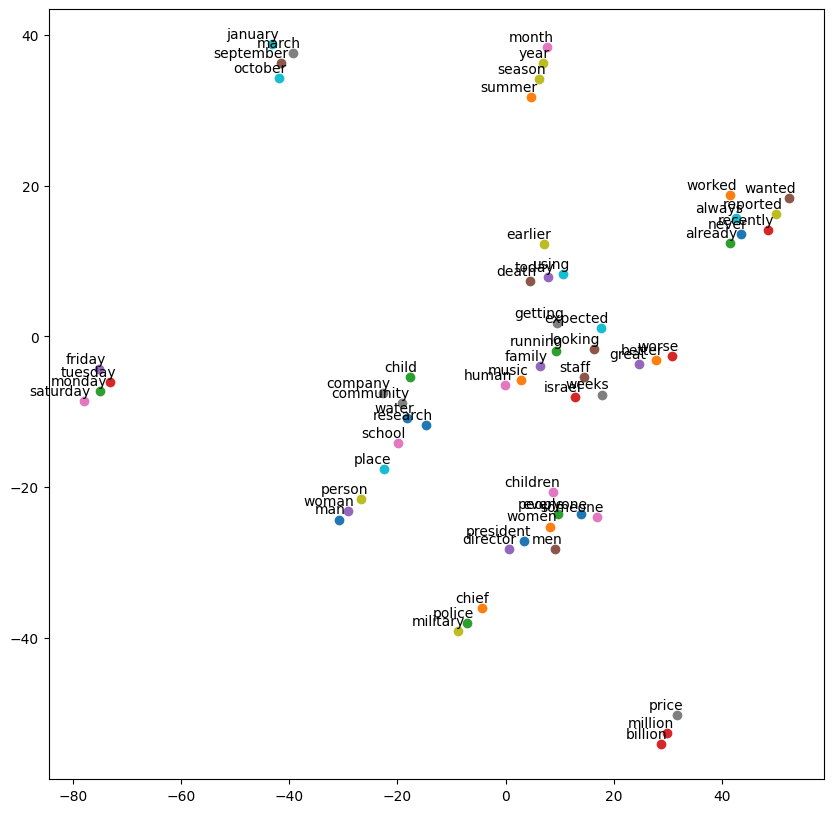

In [50]:
embeddings = embeddings_cargados
targets = "data/target_words.txt"
words = load_corpus(targets)[0]
# word_to_id = {str(word): i for i, word in enumerate(vocab)}
# id_to_word = {v: k for k, v in word_to_id.items()}


# Example usage of the first function
def example_plot_1():
    #["word_1", "word_2", "word_3", "word_4", "word_5"]  # Select some words to plot
    visualize_tsne_embeddings(words, embeddings, word_to_id, filename="plot_1.png")

# Example usage of the second function
#def example_plot_2():
    # words_to_plot = ["word_10", "word_20", "word_30", "word_40", "word_50"]  # Select some words to plot
    # words_to_label = ["word_10", "word_30", "word_50"]  # Select some words to label
    # visualize_all_tsne_embeddings(embeddings, word_index, words_to_plot, words_to_label, filename="plot_2.png")

example_plot_1()
#example_plot_2()